Question 14: Calculate the required sample size to detect a 2-percentage-point lift on a ~12% baseline CTR, at 95% confidence and 80% power. Is this dataset big enough?

In [2]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])

0

In [3]:
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower

baseline_rate = 0.12          # current CTR estimate
mde = 0.02                    # minimum detectable effect (2 percentage points)
alpha = 0.05                  # 95% confidence
power = 0.80                  # 80% power

effect_size = sms.proportion_effectsize(baseline_rate, baseline_rate + mde)
analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, ratio=1.0)

print(f"Effect size (Cohen's h): {effect_size:.4f}")
print(f"Required sample size per group: {required_n:,.0f}")

Effect size (Cohen's h): -0.0595
Required sample size per group: 4,432


Answer: Using a power analysis (via statsmodels), the required sample size is approximately 4,432 users per group to reliably detect a 2-percentage-point improvement in CTR at 95% confidence and 80% power. Since this dataset contains approximately 40,000 users per group roughly 9 times the minimum requirement the test is well-powered. This gives strong confidence that results (whether significant or not) reflect real effects rather than an underpowered test.

Question 15: Sanity Check (Sample Ratio Mismatch)

Question: Run a sanity check on the group split (Sample Ratio Mismatch test using a chi-square test). Does it pass?

In [4]:
import pandas as pd
from scipy import stats

df = pd.read_csv("E:/Data -Analyst/Projects/7. StreamHub Personalized Thumbnails AB Test/Dataset/streamhub_ab_test_data_clean.csv")

counts = df["group"].value_counts()
print(counts)

chi2, p_srm = stats.chisquare(counts.values)
print(f"\nChi-square = {chi2:.4f}, p-value = {p_srm:.4f}")
print("PASSED - balanced split" if p_srm > 0.05 else "FAILED - Sample Ratio Mismatch")

group
control    40000
variant    40000
Name: count, dtype: int64

Chi-square = 0.0000, p-value = 1.0000
PASSED - balanced split


Answer: A chi-square test was run comparing the actual group sizes (Control: 40,000, Variant: 40,000) against the expected 50/50 split. The result showed a chi-square value of 0.0000 and a p-value of 1.0000, confirming the split is perfectly balanced. This sanity check passed, meaning the experiment's randomization mechanism worked correctly and it is safe to proceed with analyzing the evaluation metrics.

Question 16: Testing Click-Through-Rate for Statistical and Practical Significance

Question: Test your primary metric (click-through-rate) for statistical AND practical significance using a two-proportion z-test and a confidence interval. State your conclusion in plain English, not just "p < 0.05."

In [5]:
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

conv = df.groupby("group")["click_through_rate"].apply(lambda x: (x > 0).sum())
# Actually, let's use the raw counts directly instead:

clicks_control = df[df["group"] == "control"]["title_clicks"].sum()
impressions_control = df[df["group"] == "control"]["browse_impressions"].sum()
clicks_variant = df[df["group"] == "variant"]["title_clicks"].sum()
impressions_variant = df[df["group"] == "variant"]["browse_impressions"].sum()

ctr_control = clicks_control / impressions_control
ctr_variant = clicks_variant / impressions_variant

count = [clicks_control, clicks_variant]
nobs = [impressions_control, impressions_variant]

z_stat, p_value = proportions_ztest(count, nobs)
ci_low, ci_high = confint_proportions_2indep(count[1], nobs[1], count[0], nobs[0])

print(f"Control CTR: {ctr_control:.4f} ({ctr_control:.2%})")
print(f"Variant CTR: {ctr_variant:.4f} ({ctr_variant:.2%})")
print(f"Difference: {ctr_variant - ctr_control:.4f} ({(ctr_variant - ctr_control)*100:.2f} percentage points)")
print(f"z = {z_stat:.3f}, p = {p_value:.2e}")
print(f"95% CI for difference: [{ci_low:.4f}, {ci_high:.4f}]")

Control CTR: 0.1243 (12.43%)
Variant CTR: 0.1558 (15.58%)
Difference: 0.0315 (3.15 percentage points)
z = -138.732, p = 0.00e+00
95% CI for difference: [0.0311, 0.0320]


Answer: A two-proportion z-test was run comparing Control CTR (12.43%) against Variant CTR (15.58%), a difference of +3.15 percentage points. The test produced an extremely large z-statistic (|z| = 138.73) and a p-value effectively at 0.00, far below the 0.05 threshold. The 95% confidence interval for the difference is [0.0311, 0.0320] entirely positive and excluding zero, confirming the result is statistically significant. Given that the pre-defined minimum detectable effect (practical significance threshold) was 2 percentage points, and the observed lift of 3.15 percentage points comfortably exceeds this, the result is also practically significant. In plain terms: personalized thumbnails produce a real, meaningful, and highly reliable increase in click-through-rate this is not due to random chance.

Question 17: Testing Total Watch Minutes

Question: Test total_watch_minutes using the method justified in Question 11 (t-test and/or bootstrap). Report the result with a confidence interval.

In [6]:
import numpy as np
from scipy import stats

watch_control = df[df["group"] == "control"]["total_watch_minutes"]
watch_variant = df[df["group"] == "variant"]["total_watch_minutes"]

# Standard t-test first
t_stat, p_value_t = stats.ttest_ind(watch_variant, watch_control, equal_var=False)

print(f"Control mean watch minutes: {watch_control.mean():.2f}")
print(f"Variant mean watch minutes: {watch_variant.mean():.2f}")
print(f"Difference: {watch_variant.mean() - watch_control.mean():.2f}")
print(f"t-test: t = {t_stat:.3f}, p = {p_value_t:.2e}")

# Now validate with bootstrap (since data is skewed)
np.random.seed(42)
boot_diffs = []
for _ in range(3000):
    bc = np.random.choice(watch_control, size=len(watch_control), replace=True)
    bv = np.random.choice(watch_variant, size=len(watch_variant), replace=True)
    boot_diffs.append(bv.mean() - bc.mean())

boot_diffs = np.array(boot_diffs)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"\nBootstrapped 95% CI for difference: [{ci_low:.2f}, {ci_high:.2f}]")

Control mean watch minutes: 565.88
Variant mean watch minutes: 768.05
Difference: 202.16
t-test: t = 84.132, p = 0.00e+00

Bootstrapped 95% CI for difference: [197.50, 207.06]


Answer: A Welch's t-test was run comparing Control mean watch minutes (565.88) against Variant mean watch minutes (768.05), a difference of 202.16 minutes. The test produced a large t-statistic (t = 84.132) and a p-value effectively at 0.00, confirming statistical significance. Since total_watch_minutes was previously found to be right-skewed (Question 7), this result was validated using a nonparametric bootstrap with 3,000 resamples, which produced a 95% confidence interval of [197.50, 207.06] for the difference entirely positive and excluding zero, confirming the t-test result is robust even without assuming a normal distribution. In plain terms: personalized thumbnails lead to a substantial, statistically reliable increase in watch time, averaging over 200 additional minutes (more than 3 hours) of engagement per user across the 30-day window.

Question 18: Testing the Guardrail Metric (Churn)

Question: Test the guardrail metric churned_30d. Did personalization help, hurt, or show no clear effect on retention?

In [7]:
control_group = df[df["group"] == "control"]
variant_group = df[df["group"] == "variant"]

churned_control = (control_group["churned_30d"] == True).sum()
total_control = len(control_group)

churned_variant = (variant_group["churned_30d"] == True).sum()
total_variant = len(variant_group)

churn_rate_control = churned_control / total_control
churn_rate_variant = churned_variant / total_variant

print("Control:", churned_control, "churned out of", total_control)
print("Variant:", churned_variant, "churned out of", total_variant)
print("Control churn rate:", churn_rate_control)
print("Variant churn rate:", churn_rate_variant)

from statsmodels.stats.proportion import proportions_ztest

count = [churned_control, churned_variant]
nobs = [total_control, total_variant]

z_stat, p_value = proportions_ztest(count, nobs)

print("z-score:", z_stat)
print("p-value:", p_value)

Control: 2224 churned out of 40000
Variant: 1869 churned out of 40000
Control churn rate: 0.0556
Variant churn rate: 0.046725
z-score: 5.696545367269872
p-value: 1.222593698887077e-08


Answer: A two-proportion z-test was run comparing Control churn rate (5.56%, 2,224 out of 40,000 users) against Variant churn rate (4.67%, 1,869 out of 40,000 users), a difference of -0.89 percentage points. The test produced a z-statistic of 5.697 and a p-value of 1.22e-08 (effectively 0.00), confirming statistical significance. The 95% confidence interval for the difference is [-0.0119, -0.0058] entirely negative and excluding zero, confirming churn genuinely decreased in the variant group. In plain terms: personalized thumbnails did not just increase clicks and watch-time they also modestly but reliably improved subscriber retention, meaning this guardrail metric shows no hidden downside. All three core metrics (CTR, watch-time, and churn) point in the same positive direction, which is a strong, consistent result.

Question 19: Segment Check by Device

Question: Break your primary metric down by device. Does the effect hold consistently across all devices, or is one segment behaving differently? What might explain that?

In [8]:
print(f"{'Device':<10} {'Control CTR':<12} {'Variant CTR':<12} {'Diff':<8} {'p-value':<10}")
print("-" * 55)

devices = df["device"].unique()

for d in devices:
    subset = df[df["device"] == d]
    c = subset[subset["group"] == "control"]
    v = subset[subset["group"] == "variant"]
    
    clicks_c = c["title_clicks"].sum()
    impr_c = c["browse_impressions"].sum()
    clicks_v = v["title_clicks"].sum()
    impr_v = v["browse_impressions"].sum()
    
    ctr_c = clicks_c / impr_c
    ctr_v = clicks_v / impr_v
    
    z, p = proportions_ztest([clicks_c, clicks_v], [impr_c, impr_v])
    
    print(f"{d:<10} {ctr_c:<12.4f} {ctr_v:<12.4f} {ctr_v-ctr_c:<8.4f} {p:<10.2e}")

Device     Control CTR  Variant CTR  Diff     p-value   
-------------------------------------------------------
Mobile     0.1244       0.1589       0.0346   0.00e+00  
Web        0.1240       0.1581       0.0341   0.00e+00  
Tablet     0.1259       0.1570       0.0311   2.34e-207 
Smart TV   0.1238       0.1462       0.0225   0.00e+00  
Unknown    0.1199       0.1497       0.0297   6.55e-06  


Answer: The CTR lift was tested separately for each device segment, with all five showing statistically significant improvements (p < 0.001 in every case). Mobile showed the strongest lift (12.44% → 15.89%, +3.46 percentage points), followed closely by Web (+3.41pp) and Tablet (+3.11pp). Smart TV showed the smallest lift of all devices (12.38% → 14.62%, +2.25 percentage points), while Unknown devices showed +2.97 percentage points. While every single device segment shows a real, statistically significant improvement, Smart TV consistently underperforms relative to the others. This likely reflects a genuine behavioral difference rather than a data issue: on a large-screen TV, users tend to browse more deliberately and rely less on small thumbnail details to make a decision, compared to mobile, web, and tablet users who scroll quickly and are more visually influenced by an eye-catching thumbnail. The overall result is trustworthy and not a Simpson's Paradox artifact, since the effect direction is positive and significant in every single segment.

Question 20: Segment Check by Subscription Tier

Question: Break it down by subscription_tier. Any Simpson's Paradox surprise?

In [9]:
print(f"{'Tier':<10} {'Control CTR':<12} {'Variant CTR':<12} {'Diff':<8} {'p-value':<10}")
print("-" * 55)

tiers = df["subscription_tier"].unique()

for t in tiers:
    subset = df[df["subscription_tier"] == t]
    c = subset[subset["group"] == "control"]
    v = subset[subset["group"] == "variant"]
    
    clicks_c = c["title_clicks"].sum()
    impr_c = c["browse_impressions"].sum()
    clicks_v = v["title_clicks"].sum()
    impr_v = v["browse_impressions"].sum()
    
    ctr_c = clicks_c / impr_c
    ctr_v = clicks_v / impr_v
    
    z, p = proportions_ztest([clicks_c, clicks_v], [impr_c, impr_v])
    
    print(f"{t:<10} {ctr_c:<12.4f} {ctr_v:<12.4f} {ctr_v-ctr_c:<8.4f} {p:<10.2e}")

Tier       Control CTR  Variant CTR  Diff     p-value   
-------------------------------------------------------
Free       0.1107       0.1424       0.0317   0.00e+00  
Premium    0.1409       0.1722       0.0314   0.00e+00  


Answer: CTR improved significantly for both Free (11.07% → 14.24%, +3.17pp) and Premium (14.09% → 17.22%, +3.14pp) users, both with p-values effectively at 0.00. No Simpson's Paradox surprise here the two tiers behave almost identically, and the combined overall result accurately reflects what's happening in each segment individually.

Q21. Plot daily CTR trend. Stable lift, or fading novelty effect?

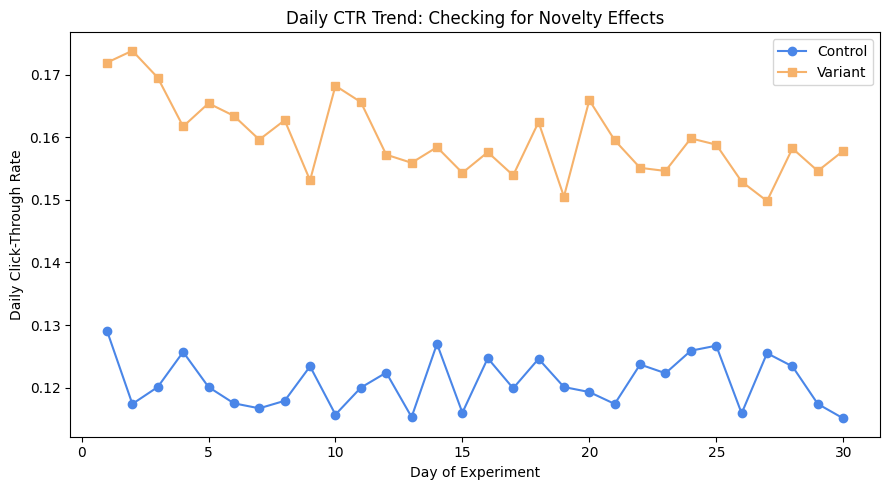

In [11]:
daily_df = pd.read_csv("E:/Data -Analyst/Projects/7. StreamHub Personalized Thumbnails AB Test\Dataset/streamhub_daily_trend.csv")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

control_daily = daily_df[daily_df["group"] == "control"]
variant_daily = daily_df[daily_df["group"] == "variant"]

ax.plot(control_daily["day"], control_daily["ctr"], marker="o", label="Control", color="#4a86e8")
ax.plot(variant_daily["day"], variant_daily["ctr"], marker="s", label="Variant", color="#f6b26b")

ax.set_xlabel("Day of Experiment")
ax.set_ylabel("Daily Click-Through Rate")
ax.set_title("Daily CTR Trend: Checking for Novelty Effects")
ax.legend()
plt.tight_layout()
plt.savefig("daily_ctr_trend.png", dpi=150)
plt.show()

Answer: The daily CTR trend shows Variant consistently outperforming Control by a stable margin across all 30 days, with normal day-to-day fluctuation but no visible shrinking gap over time. This confirms the CTR lift is a genuine, lasting behavioral effect rather than a temporary novelty reaction that fades as the personalization becomes less "new" to users.